Initializing Fixed Income Investment Allocator Pipeline...

--- Detailed Fixed Income Simulation Summary ---


,Asset,Gross_Final,Cost,Tax_Amount,Net_Final,Net_Profit,Net_Rate_Annual
0,Tesouro Prefixado,1959.43,5.73,143.06,1810.65,810.65,12.61
1,Poupança,1424.98,0.00,0.00,1424.98,424.98,7.34
2,CDB,1595.92,0.00,89.39,1506.53,506.53,8.54
3,LCI/LCA,1510.60,0.00,0.00,1510.60,510.60,8.60
4,Fundo DI,1595.92,0.00,89.39,1506.53,506.53,8.54


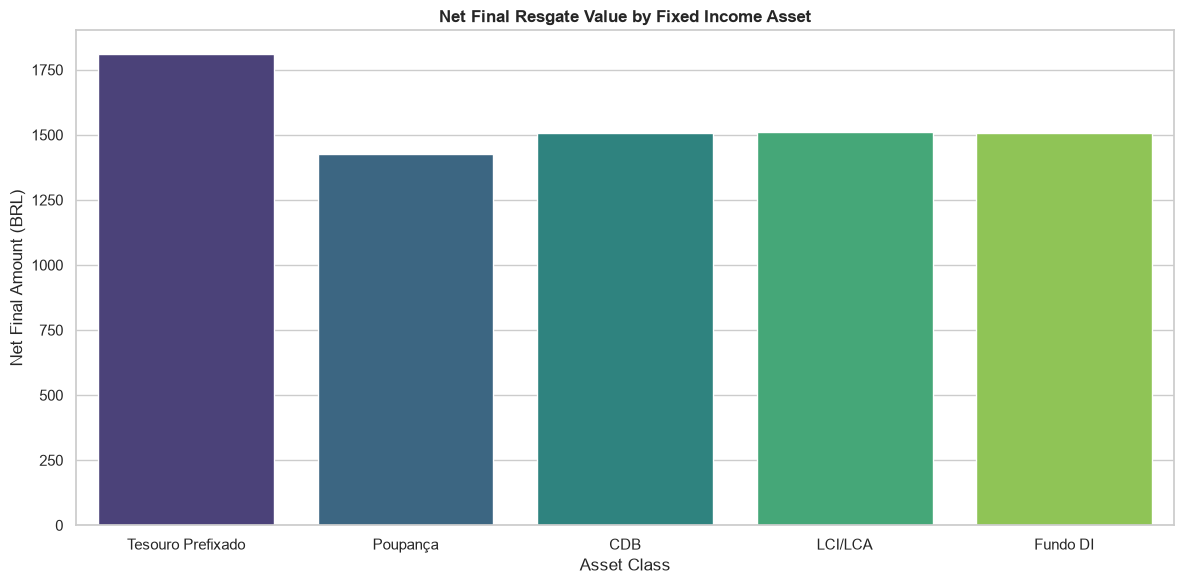

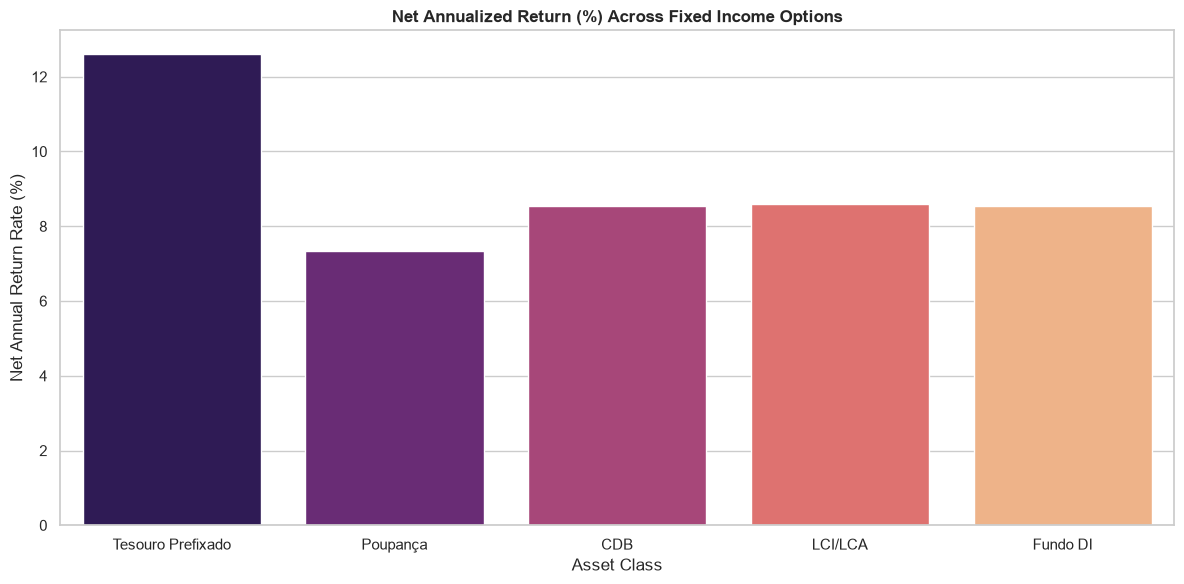

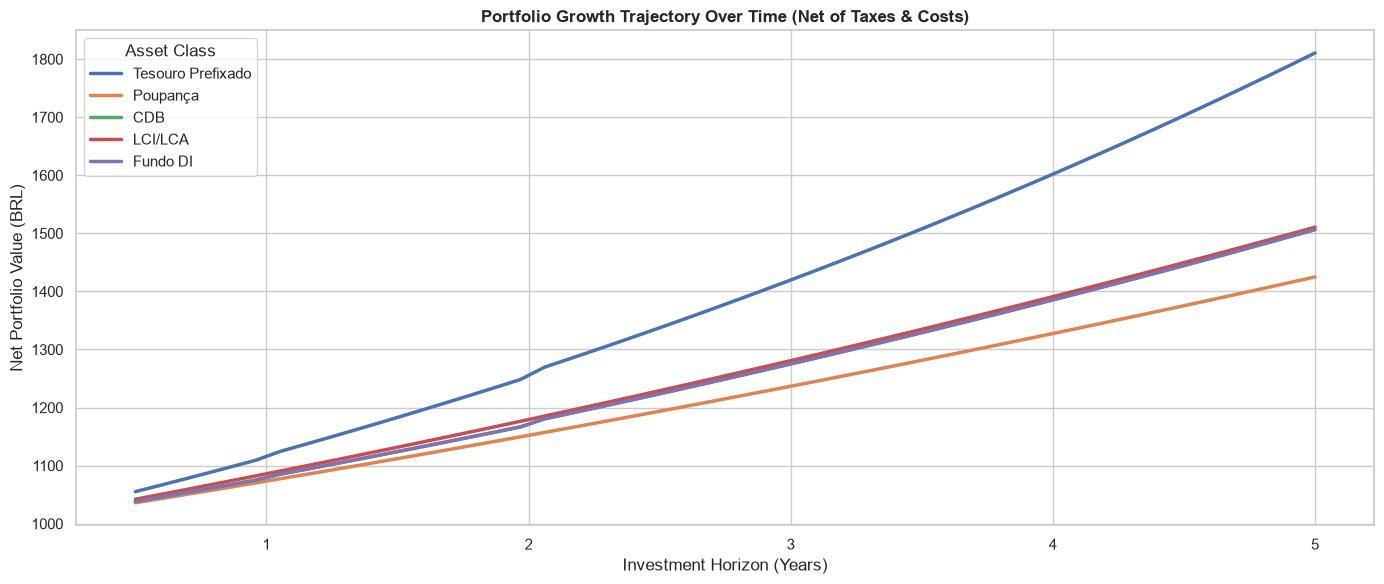

In [ ]:
"""
===============================================================================
Project: Fixed Income Investment Strategy & Horizon Allocator
Author: Joao Zimmer
Description: 
    This script performs a comparative exploratory analysis of fixed income 
    investment options (Tesouro Prefixado, Poupança, CDB, LCI/LCA, and Fundo DI) 
    based on official multi-asset simulation benchmarks, including time-series 
    growth trajectories.

The analysis pipeline includes:
    1. Structured data ingestion reflecting official benchmarking parameters.
    2. Tax structure simulation (Regressive IR and tax-exempt brackets).
    3. Net yield comparisons, cost deductions, and performance profiling.
    4. Advanced data visualizations using Matplotlib and Seaborn (Barplots & Time-Series).
===============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional visual configurations for Seaborn aesthetics
sns.set_theme(style="whitegrid")

print("Initializing Fixed Income Investment Allocator Pipeline...")

# --- 1. Define Official Simulation Parameters ---
initial_investment = 1000.0

assets_params = {
    'Tesouro Prefixado': {'gross_rate': 0.1440, 'cost': 5.73, 'tax_exempt': False},
    'Poupança':          {'gross_rate': 0.0734, 'cost': 0.00, 'tax_exempt': True},
    'CDB':               {'gross_rate': 0.0980, 'cost': 0.00, 'tax_exempt': False},
    'LCI/LCA':           {'gross_rate': 0.0860, 'cost': 0.00, 'tax_exempt': True},
    'Fundo DI':          {'gross_rate': 0.0980, 'cost': 0.00, 'tax_exempt': False}
}

years_benchmark = 5
days_benchmark = int(years_benchmark * 365)

# --- 2. Calculation & Simulation Function ---
simulation_data = []

for asset_name, params in assets_params.items():
    gross_rate = params['gross_rate']
    cost = params['cost']
    tax_exempt = params['tax_exempt']
    
    gross_final = initial_investment * ((1 + gross_rate) ** years_benchmark)
    gross_profit = gross_final - initial_investment
    adjusted_profit_for_tax = max(0, gross_profit - cost)
    
    if tax_exempt:
        tax_rate = 0.0
        tax_amount = 0.0
    else:
        if days_benchmark <= 180:
            tax_rate = 0.225
        elif days_benchmark <= 360:
            tax_rate = 0.20
        elif days_benchmark <= 720:
            tax_rate = 0.175
        else:
            tax_rate = 0.15
        tax_amount = adjusted_profit_for_tax * tax_rate
        
    net_final = gross_final - cost - tax_amount
    net_profit = net_final - initial_investment
    net_rate = ((net_final / initial_investment) ** (1 / years_benchmark)) - 1
    
    simulation_data.append({
        'Asset': asset_name,
        'Gross_Final': gross_final,
        'Cost': cost,
        'Tax_Amount': tax_amount,
        'Net_Final': net_final,
        'Net_Profit': net_profit,
        'Net_Rate_Annual': net_rate * 100
    })

df_results = pd.DataFrame(simulation_data)

print("\n--- Detailed Fixed Income Simulation Summary ---")
display(df_results.round(2))

# --- 3. Exploratory Data Visualization ---

# 1. Net Final Amount Comparison Barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Asset', y='Net_Final', hue='Asset', palette='viridis', legend=False)
plt.title('Net Final Resgate Value by Fixed Income Asset', fontsize=12, fontweight='bold')
plt.xlabel('Asset Class')
plt.ylabel('Net Final Amount (BRL)')
plt.tight_layout()
plt.show()

# 2. Net Annual Return Percentage Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Asset', y='Net_Rate_Annual', hue='Asset', palette='magma', legend=False)
plt.title('Net Annualized Return (%) Across Fixed Income Options', fontsize=12, fontweight='bold')
plt.xlabel('Asset Class')
plt.ylabel('Net Annual Return Rate (%)')
plt.tight_layout()
plt.show()

# 3. Trajectory Over Time (Line Plot across Years)
time_points = np.linspace(0.5, years_benchmark, 50)
trajectory_data = []

for t in time_points:
    t_days = int(t * 365)
    for asset_name, params in assets_params.items():
        g_rate = params['gross_rate']
        c_val = params['cost'] * (t / years_benchmark) # Prorating custody costs over time
        t_exempt = params['tax_exempt']
        
        g_val = initial_investment * ((1 + g_rate) ** t)
        g_prof = g_val - initial_investment
        adj_prof = max(0, g_prof - c_val)
        
        if t_exempt:
            t_amt = 0.0
        else:
            if t_days <= 180:
                tx_r = 0.225
            elif t_days <= 360:
                tx_r = 0.20
            elif t_days <= 720:
                tx_r = 0.175
            else:
                tx_r = 0.15
            t_amt = adj_prof * tx_r
            
        n_val = g_val - c_val - t_amt
        
        trajectory_data.append({
            'Time_Years': t,
            'Asset': asset_name,
            'Net_Value': n_val
        })

df_trajectory = pd.DataFrame(trajectory_data)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trajectory, x='Time_Years', y='Net_Value', hue='Asset', linewidth=2.5)
plt.title('Portfolio Growth Trajectory Over Time (Net of Taxes & Costs)', fontsize=12, fontweight='bold')
plt.xlabel('Investment Horizon (Years)')
plt.ylabel('Net Portfolio Value (BRL)')
plt.legend(title='Asset Class')
plt.tight_layout()
plt.show()